In [16]:
!pip install pandas matplotlib seaborn

In [17]:
import pandas as pd

raw = [
    {"date":"2026-01-01","store":"A","menu":"Americano","price":"4500원","qty":"2","paid":"TRUE"},
    {"date":"2026/01/01","store":"A","menu":"Latte","price":"5,000","qty":1,"paid":"True"},
    {"date":"2026-01-02","store":"A","menu":"Latte","price":None,"qty":2,"paid":"FALSE"},
    {"date":"2026-01-03","store":"B","menu":"Mocha","price":"5500","qty":None,"paid":True},
    {"date":"2026-01-03","store":"B","menu":"Americano","price":"4500","qty":1,"paid":"TRUE"},
    {"date":"2026-01-04","store":"B","menu":"Latte","price":"5000원","qty":"3","paid":"TRUE"},
]
df = pd.DataFrame(raw)
df.head()

,date,store,menu,price,qty,paid
0,2026-01-01,A,Americano,4500원,2,TRUE
1,2026/01/01,A,Latte,"5,000",1,True
2,2026-01-02,A,Latte,None,2,FALSE
3,2026-01-03,B,Mocha,5500,None,True
4,2026-01-03,B,Americano,4500,1,TRUE


In [18]:
import numpy as np

# 날짜
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# price 숫자화: "4500원", "5,000" 처리
df["price"] = (df["price"].astype("string")
               .str.replace(",", "", regex=False)
               .str.replace("원", "", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# qty 숫자화
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")

# paid bool로 통일
df["paid"] = (df["paid"].astype("string").str.upper() == "TRUE")

# 매출
df["sales"] = df["price"] * df["qty"]

df

,date,store,menu,price,qty,paid,sales
0,2026-01-01,A,Americano,4500,2.0,True,9000.0
1,NaT,A,Latte,5000,1.0,True,5000.0
2,2026-01-02,A,Latte,<NA>,2.0,False,<NA>
3,2026-01-03,B,Mocha,5500,NaN,True,<NA>
4,2026-01-03,B,Americano,4500,1.0,True,4500.0
5,2026-01-04,B,Latte,5000,3.0,True,15000.0


In [19]:
import matplotlib.pyplot as plt

daily = df.groupby("date", as_index=False)["sales"].sum()

daily

,date,sales
0,2026-01-01,9000.0
1,2026-01-02,0.0
2,2026-01-03,4500.0
3,2026-01-04,15000.0


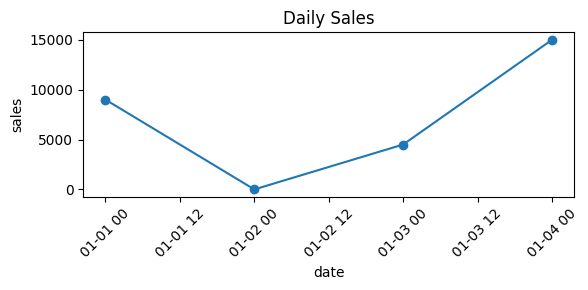

In [20]:
plt.figure(figsize=(6,3))
plt.plot(daily["date"], daily["sales"], marker="o")
plt.title("Daily Sales")
plt.xlabel("date")
plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

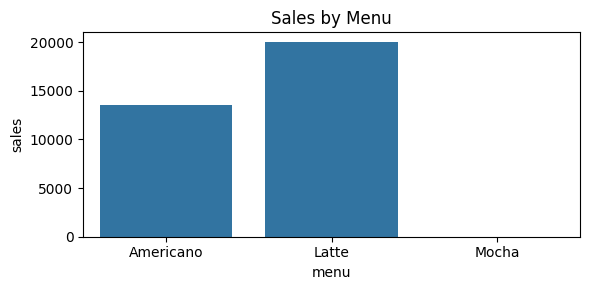

In [21]:
import seaborn as sns

menu_sales = df.groupby("menu", as_index=False)["sales"].sum()

plt.figure(figsize=(6,3))
sns.barplot(data=menu_sales, x="menu", y="sales")
plt.title("Sales by Menu")
plt.tight_layout()
plt.show()

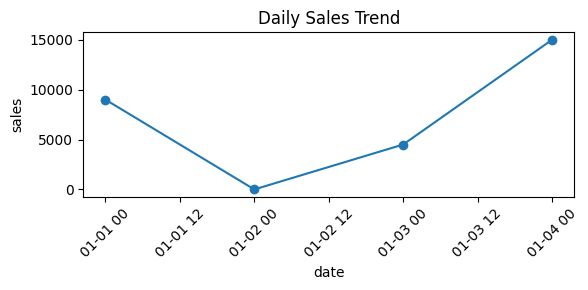

In [22]:
daily = df.groupby("date", as_index=False)["sales"].sum().sort_values("date")

plt.figure(figsize=(6,3))
plt.plot(daily["date"], daily["sales"], marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("date"); plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df_a = df[df["store"] == "A"].dropna(subset=["date"]).copy()

df_a

,date,store,menu,price,qty,paid,sales
0,2026-01-01,A,Americano,4500,2.0,True,9000.0
2,2026-01-02,A,Latte,<NA>,2.0,False,<NA>


In [31]:
df_b = df[df["store"] == "B"].dropna(subset=["date"]).copy()
daily_b = df_b.groupby("date", as_index=False)["sales"].sum().sort_values("date")
daily_b

,date,sales
0,2026-01-03,4500.0
1,2026-01-04,15000.0


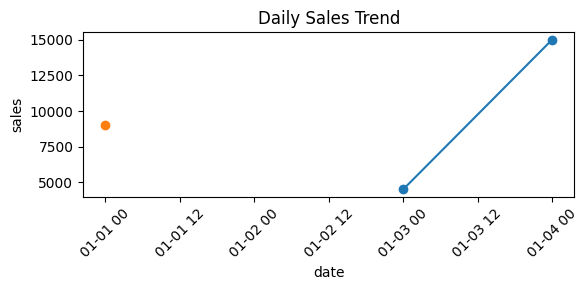

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(daily_a["date"], daily_a["sales"], color="tab:orange", marker="o", label="A")
plt.plot(daily_b["date"], daily_b["sales"], color="tab:blue", marker="o", label="B")
plt.title("Daily Sales Trend")
plt.xlabel("date"); plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

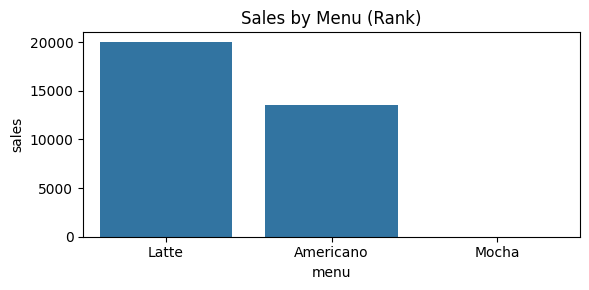

In [32]:
menu_sales = (df.groupby("menu", as_index=False)["sales"]
              .sum()
              .sort_values("sales", ascending=False))

plt.figure(figsize=(6,3))
sns.barplot(data=menu_sales, x="menu", y="sales")
plt.title("Sales by Menu (Rank)")
plt.tight_layout()
plt.show()

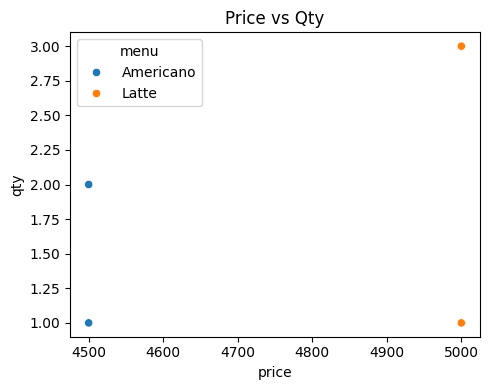

In [34]:
tmp = df.dropna(subset=["price","qty"])

plt.figure(figsize=(5,4))
sns.scatterplot(data=tmp, x="price", y="qty", hue="menu")
plt.title("Price vs Qty")
plt.tight_layout()
plt.show()

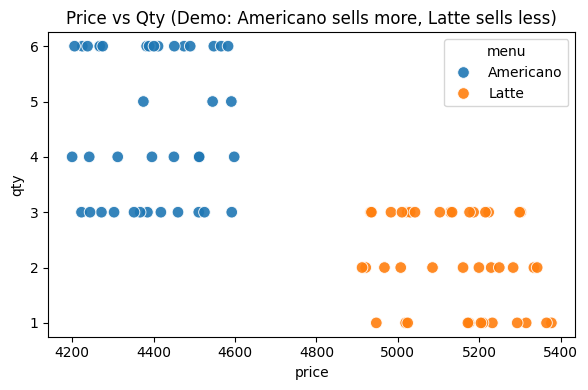

,menu,price,qty,sales
0,Americano,4375,5,21875
1,Americano,4396,4,17584
2,Americano,4225,6,25350
3,Americano,4267,6,25602
4,Americano,4411,6,26466


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)

n = 40  # 점 개수(원하는 만큼 늘려도 됨)

# Americano: 저가 + 수량 많음
a_price = np.random.randint(4200, 4601, size=n)
a_qty   = np.random.randint(3, 7, size=n)   # 3~6

# Latte: 고가 + 수량 적음
l_price = np.random.randint(4900, 5401, size=n)
l_qty   = np.random.randint(1, 4, size=n)   # 1~3

df_demo = pd.DataFrame({
    "menu":  ["Americano"] * n + ["Latte"] * n,
    "price": np.concatenate([a_price, l_price]),
    "qty":   np.concatenate([a_qty, l_qty]),
})

# (선택) 판매금액도 같이 보고 싶으면
df_demo["sales"] = df_demo["price"] * df_demo["qty"]

# 산점도
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_demo, x="price", y="qty", hue="menu", s=70, alpha=0.9)

plt.title("Price vs Qty (Demo: Americano sells more, Latte sells less)")
plt.xlabel("price")
plt.ylabel("qty")
plt.tight_layout()
plt.show()

df_demo.head()

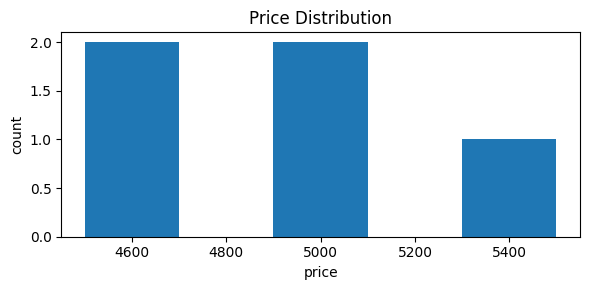

In [36]:
tmp = df.dropna(subset=["price"])

plt.figure(figsize=(6,3))
plt.hist(tmp["price"], bins=5)
plt.title("Price Distribution")
plt.xlabel("price")
plt.ylabel("count")
plt.tight_layout()
plt.show()

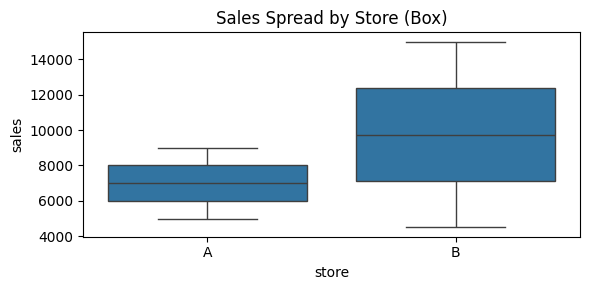

In [39]:
tmp = df.dropna(subset=["sales"])

plt.figure(figsize=(6,3))
sns.boxplot(data=tmp, x="store", y="sales")
plt.title("Sales Spread by Store (Box)")
plt.tight_layout()
plt.show()

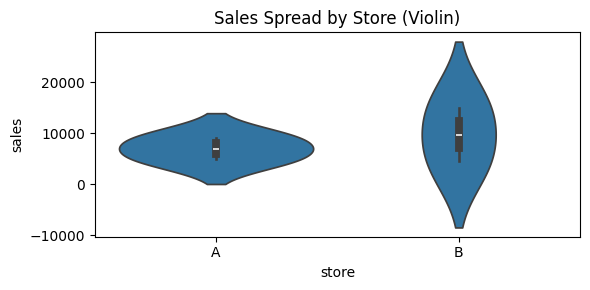

In [38]:
plt.figure(figsize=(6,3))
sns.violinplot(data=tmp, x="store", y="sales")
plt.title("Sales Spread by Store (Violin)")
plt.tight_layout()
plt.show()